In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [18]:
import surfinBH
import lal
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sxs
lal.swig_redirect_standard_output_error(False)

False

In [19]:
def GR_iter_max ( g, x_min, x_max, prec) :
   
   x_1 = 0.
   x_2 = 0.
   r = 0.618	
   L = abs(x_min - x_max)
   iter_count = 0
   while (L > prec) :
      iter_count += 1  
      x_1 = x_min + (r * (x_max - x_min))
      x_2 = x_min + ((1. - r) * (x_max - x_min))
   
      if ( g(x_2) < g(x_1) ) :         
         x_min = x_2
      
      else : 
         x_max = x_1 
               
      L = abs(x_min - x_max)
   return (x_min + x_max) / 2 

Loaded NRSur7dq4EmriRemnant fit.


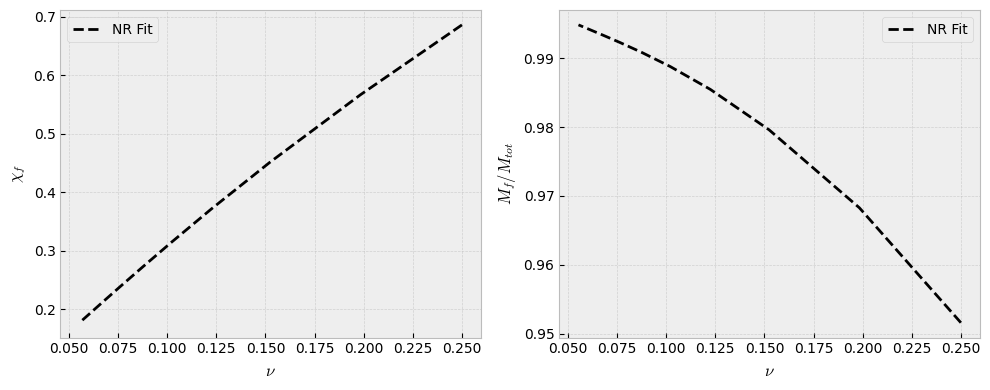

In [20]:
fit = surfinBH.LoadFits('NRSur7dq4EmriRemnant')

# SIMMETRIC MASS RATIO 
q_values = np.linspace(1, 16, 10)
nu_values = q_values / ((1 + q_values)**2)

final_mass = []
final_spin = []
chiA = [0, 0, 0]
chiB = [0, 0, 0]


# REMNANT PARAMETERS
for q in q_values:
    
    mf, chif, vf, mf_err, chif_err, vf_err = fit.all(q, chiA, chiB)
    final_mass.append(mf)
    chif_norm = np.linalg.norm(chif)
    final_spin.append(chif_norm)


# GRAPHS
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# mass graph
ax[1].plot(nu_values, final_mass, color='black', linewidth=2, linestyle='--', label='NR Fit')
ax[1].set_ylabel(r'$M_f / M_{tot}$') # La 'r' permette di usare LaTeX per le formule
ax[1].set_xlabel(r'$\nu$')

# spin graph
ax[0].plot(nu_values, final_spin, color='black', linewidth=2, linestyle='--', label='NR Fit')
ax[0].set_ylabel(r'$\chi_f$')
ax[0].set_xlabel(r'$\nu$')

for a in ax:
    
    a.grid(True, alpha=0.5) # Aggiunge una griglia leggera
    a.legend()

plt.tight_layout() # Sistema gli spazi tra i grafici automaticamente
plt.show()

In [21]:
#POST-NEWTONIAN MASS
#from now on Mtot = 1
def PN_mass(nu, j, order=4):
    
    # Inizializziamo i termini delle correzioni a 0
    term_1PN = 0
    term_2PN = 0
    term_3PN = 0
    term_4PN = 0
    
    # 1PN: 1/j^2
    if order >= 1:
        term_1PN = ((9 + nu) / 4) * (1 / j**2)
        
    # 2PN:  1/j^4
    if order >= 2:
        term_2PN = ((81 - 7*nu + nu**2) / 8) * (1 / j**4)
        
    # 3PN:  1/j^6
    if order >= 3:
        term_3PN = (3861/64 + (41 * np.pi**2 / 32 - 8833/192) * nu - 
                    (5 * nu**2 / 32) + (5 * nu**3 / 64)) * (1 / j**6)
        
    # 4PN:  1/j^8
    if order >= 4:
        gamma_E = np.euler_gamma  
        log_term = np.log(4 / j)
        c4_nu1 = (6581 * np.pi**2 / 512 - 989911/1920 - 128/5 * (gamma_E + log_term)) * nu
        c4_nu2 = (8875/384 - 41 * np.pi**2 / 64) * nu**2
        c4_nu34 = - (3 * nu**3 / 64) + (7 * nu**4 / 128) + 53703/128
        term_4PN = (c4_nu1 + c4_nu2 + c4_nu34) * (1 / j**8)
    
    bracket = 1 + term_1PN + term_2PN + term_3PN + term_4PN
    
    return 1 - (nu / (2 * j**2)) * bracket


In [22]:
#KERR ENTROPY
def Kerr_entropy (nu, j, order = 4) :
    M = PN_mass(nu, j, order)
    J = nu * j
    chi_sq = (J**2) / (M**4)

    if M <= 0: return np.nan
    
    if chi_sq > 1.0:
        return np.nan

    horizon_area = 8 * np.pi * (1 + np.sqrt(1 - chi_sq)) * M**2
    s = horizon_area / (16 * np.pi)
    return s


In [23]:
#MAXIMUS IDENTIFICATION

PN_orders = [0, 1, 2, 3, 4]

results = {
    o: {'mass_f': [], 'spin_f': []} for o in PN_orders
}

for o in PN_orders:
    
    for nu in nu_values:
        def g(j_val):
            return Kerr_entropy(nu, j_val, o)
        
        j_min = 2.0
        j_max = 1.0 / nu
        
        j_star = GR_iter_max(g, j_min, j_max, prec=1e-6)
        
        mf_prediction = PN_mass(nu, j_star, o)
        
        chif_prediction = (nu * j_star) / (mf_prediction**2)
        
        # Salvataggio nei contenitori
        results[o]['mass_f'].append(mf_prediction)
        results[o]['spin_f'].append(chif_prediction)



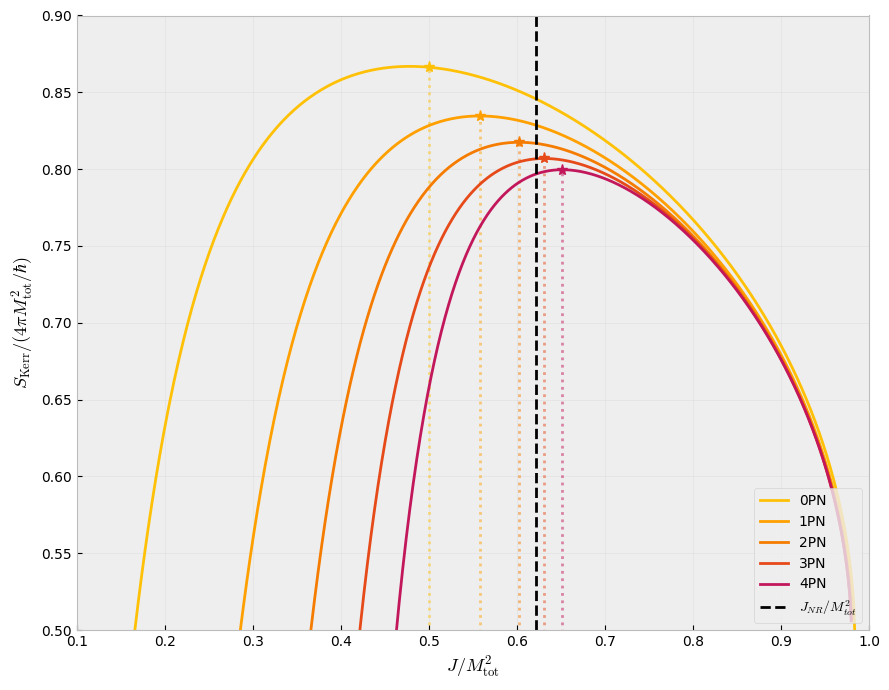

In [24]:
#FIGURE 1
#nu = 0.25

nu_val = 0.25  
j_range = np.linspace(0.5, 4.5, 1000) 
colors_map = {0: '#ffc107', 1: '#ffa000', 2: '#f57c00', 3: '#e64a19', 4: '#c2185b'}

plt.figure(figsize=(9, 7))

idx_q1 = np.argmin(np.abs(nu_values - 0.25))
j_nr_reference = final_spin[idx_q1] * (final_mass[idx_q1]**2)

for o in PN_orders:
    x_axis = nu_val * j_range
    y_axis = [Kerr_entropy(nu_val, j, o) for j in j_range]
    
    def g_obj(j_v): return Kerr_entropy(nu_val, j_v, o)
    j_star = GR_iter_max(g_obj, 2, 4.5, 1e-6)
    s_max = Kerr_entropy(nu_val, j_star, o)
    x_star = nu_val * j_star
    
    plt.plot(x_axis, y_axis, color=colors_map[o], label=f'{o}PN', linewidth=2)

    plt.plot(x_star, s_max, marker='*', color=colors_map[o], markersize=8)
    plt.vlines(x_star, 0, s_max, colors=colors_map[o], linestyles='dotted', alpha=0.5)

plt.axvline(j_nr_reference, color='black', linestyle='--', linewidth=2, label=r'$J_{NR}/M_{tot}^2$')

plt.xlabel(r'$J/M_{\rm tot}^2$', fontsize=13)
plt.ylabel(r'$S_{\rm Kerr}/(4\pi M_{\rm tot}^2/\hbar)$', fontsize=13)
plt.xlim(0.1, 1.0)
plt.ylim(0.5, 0.9)
plt.grid(True, which='both', linestyle='-', alpha=0.2)
plt.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

NR reference:
J_NR/M_tot^2 = 0.62162574
a_NR_eff     = 6.18269694


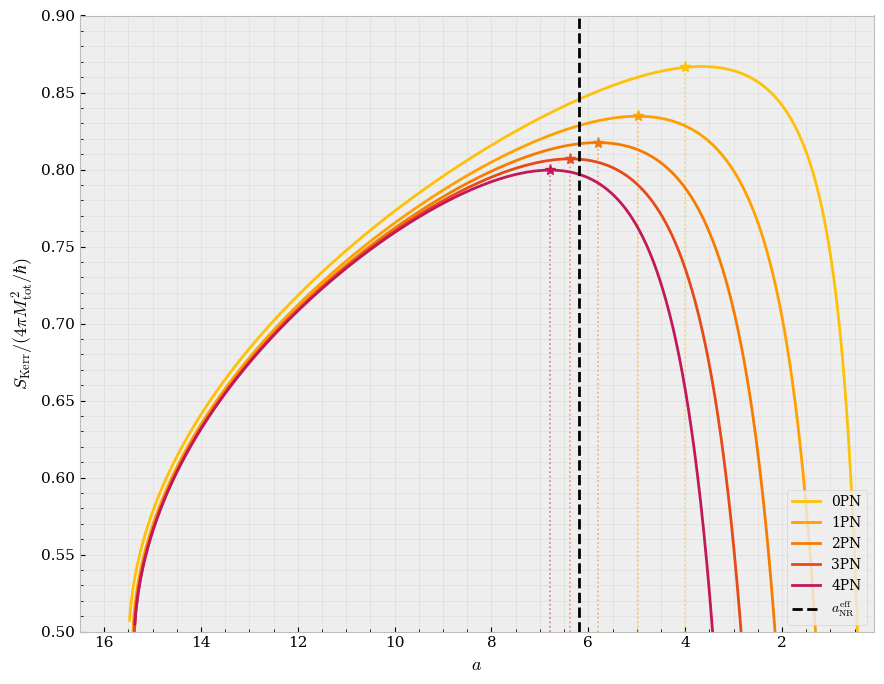

,PN_order,j_star,a_star_eff,J_over_M2_star,S_star,a_NR_eff,delta_a_eff,abs_delta_a_eff
0,0PN,2.000000,4.000002,0.500000,0.866333,6.182697,-2.182695,2.182695
1,1PN,2.231747,4.980695,0.557937,0.834607,6.182697,-1.202002,1.202002
2,2PN,2.410216,5.809141,0.602554,0.817481,6.182697,-0.373556,0.373556
3,3PN,2.524465,6.372925,0.631116,0.806940,6.182697,0.190228,0.190228
4,4PN,2.605991,6.791190,0.651498,0.799627,6.182697,0.608493,0.608493


Saved:
data/final_results/figures/paper_reproduction/maximum_entropy_reproduction_entropy_vs_a_eff.png
data/final_results/figures/paper_reproduction/maximum_entropy_reproduction_entropy_vs_a_eff.pdf


In [34]:
# ============================================================
# REPRODUCTION OF MAXIMUM ENTROPY PAPER FIGURE
# Same style as S(J), but plotted as S(a_eff)
# with a_eff = j^2
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# SETTINGS
# ============================================================

PN_orders = [0, 1, 2, 3, 4]

nu_val = 0.25

j_min = 0.5
j_max = 4.5
n_points = 2000

j_range = np.linspace(j_min, j_max, n_points)

# Effective Newtonian separation
a_eff_range = j_range**2

colors_map = {
    0: "#ffc107",
    1: "#ffa000",
    2: "#f57c00",
    3: "#e64a19",
    4: "#c2185b",
}

markers_map = {
    0: "*",
    1: "*",
    2: "*",
    3: "*",
    4: "*",
}

save_figure = True

figure_dir = Path("data/final_results/figures/paper_reproduction")
figure_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# NR REFERENCE CONVERTED TO a_eff
# ============================================================

idx_q1 = np.argmin(np.abs(nu_values - nu_val))

j_nr_reference = final_spin[idx_q1] * (final_mass[idx_q1]**2)

# Original paper x-coordinate:
J_nr_over_M2 = j_nr_reference

# Since J/M_tot^2 = nu*j, one has j = (J/M_tot^2)/nu
# and therefore a_eff = j^2.
a_nr_reference = (J_nr_over_M2 / nu_val)**2

print("NR reference:")
print(f"J_NR/M_tot^2 = {j_nr_reference:.8f}")
print(f"a_NR_eff     = {a_nr_reference:.8f}")


# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(9, 7))

summary_rows = []

for order in PN_orders:

    S_values = np.array(
        [
            Kerr_entropy(nu_val, j, order)
            for j in j_range
        ],
        dtype=float,
    )

    def g_obj(j_v):
        return Kerr_entropy(nu_val, j_v, order)

    j_star = GR_iter_max(
        g_obj,
        2.0,
        4.5,
        prec=1e-6,
    )

    a_star = j_star**2
    S_star = Kerr_entropy(nu_val, j_star, order)

    J_over_M2_star = nu_val * j_star

    ax.plot(
        a_eff_range,
        S_values,
        color=colors_map[order],
        label=f"{order}PN",
        linewidth=2.0,
    )

    ax.plot(
        a_star,
        S_star,
        marker=markers_map[order],
        color=colors_map[order],
        markersize=8,
        linestyle="None",
    )

    ax.vlines(
        a_star,
        ymin=0.0,
        ymax=S_star,
        colors=colors_map[order],
        linestyles="dotted",
        alpha=0.55,
        linewidth=1.2,
    )

    summary_rows.append({
        "PN_order": f"{order}PN",
        "j_star": j_star,
        "a_star_eff": a_star,
        "J_over_M2_star": J_over_M2_star,
        "S_star": S_star,
        "a_NR_eff": a_nr_reference,
        "delta_a_eff": a_star - a_nr_reference,
        "abs_delta_a_eff": abs(a_star - a_nr_reference),
    })


ax.axvline(
    a_nr_reference,
    color="black",
    linestyle="--",
    linewidth=2.0,
    label=r"$a_{\rm NR}^{\rm eff}$",
)


# ============================================================
# FORMATTING
# ============================================================

ax.set_xlabel(r"$a$", fontsize=13)
ax.set_ylabel(
    r"$S_{\rm Kerr}/(4\pi M_{\rm tot}^{2}/\hbar)$",
    fontsize=13,
)

# Same visual idea as the original plot, but in a_eff.
# The original x range J/M^2 in [0.1, 1.0] corresponds approximately to
# a_eff = (J/(nu M^2))^2. For nu=0.25 this is [0.16, 16].
ax.set_xlim(0.1, 16.5)
ax.set_ylim(0.5, 0.9)

ax.grid(
    True,
    which="both",
    linestyle="-",
    alpha=0.2,
)

ax.minorticks_on()

ax.legend(
    loc="lower right",
    frameon=True,
    fontsize=10,
)

fig.tight_layout()

ax.invert_xaxis()

plt.show()


# ============================================================
# SUMMARY TABLE
# ============================================================

try:
    import pandas as pd

    paper_reproduction_a_summary = pd.DataFrame(summary_rows)

    display(paper_reproduction_a_summary)

except Exception:
    print(summary_rows)


# ============================================================
# SAVE
# ============================================================

if save_figure:

    png_path = figure_dir / "maximum_entropy_reproduction_entropy_vs_a_eff.png"
    pdf_path = figure_dir / "maximum_entropy_reproduction_entropy_vs_a_eff.pdf"

    fig.savefig(
        png_path,
        dpi=400,
        bbox_inches="tight",
        pad_inches=0.08,
        facecolor="white",
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
        pad_inches=0.08,
        facecolor="white",
    )

    print("Saved:")
    print(png_path)
    print(pdf_path)

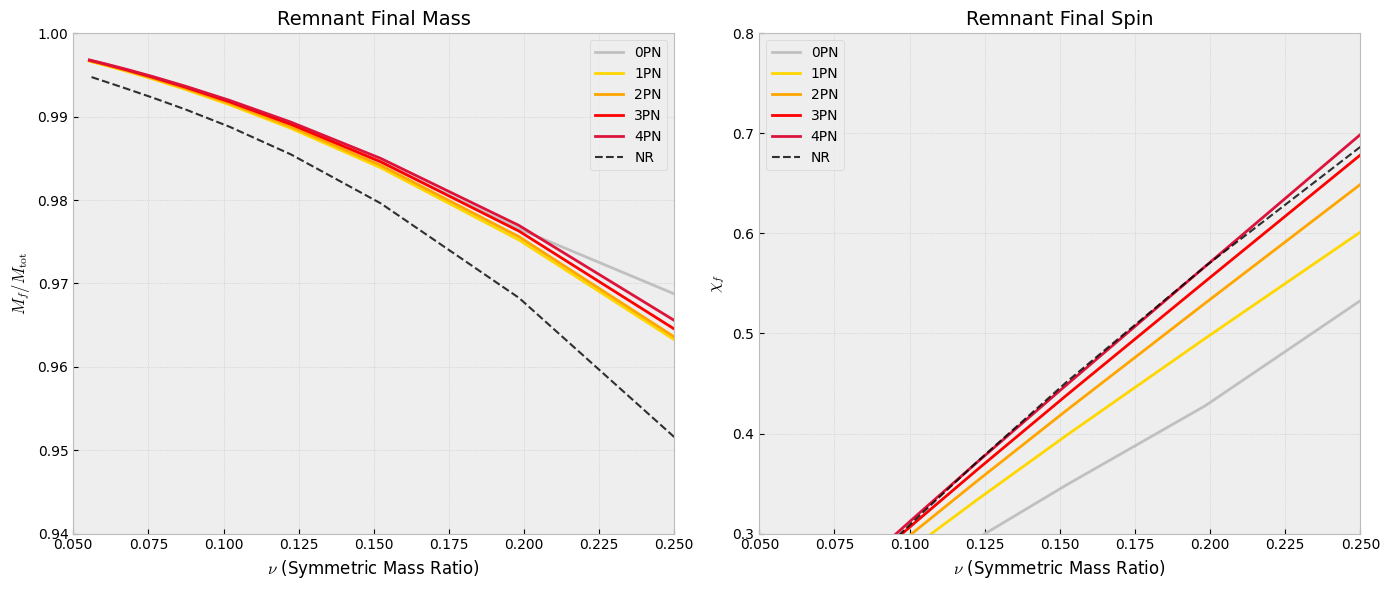

In [15]:
#FIGURE 2

plt.style.use('bmh') 
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

colors_map = {0: 'silver', 1: 'gold', 2: 'orange', 3: 'red', 4: 'crimson'}

for o in PN_orders:
    label_pn = f'{o}PN'
    
    ax[0].plot(nu_values, results[o]['mass_f'], 
               color=colors_map[o], label=label_pn, linewidth=2)
    
    ax[1].plot(nu_values, results[o]['spin_f'], 
               color=colors_map[o], label=label_pn, linewidth=2)

ax[0].plot(nu_values, final_mass, color='black', linestyle='--', 
           label='NR', linewidth=1.5, alpha=0.8)
ax[1].plot(nu_values, final_spin, color='black', linestyle='--', 
           label='NR', linewidth=1.5, alpha=0.8)



ax[0].set_title("Remnant Final Mass", fontsize=14)
ax[0].set_ylabel(r"$M_f / M_{\rm tot}$", fontsize=12)
ax[0].set_ylim(0.94, 1.0) 

ax[1].set_title("Remnant Final Spin", fontsize=14)
ax[1].set_ylabel(r"$\chi_f$", fontsize=12)
ax[1].set_ylim(0.3, 0.8)

for a in ax:
    a.set_xlabel(r"$\nu$ (Symmetric Mass Ratio)", fontsize=12)
    a.set_xlim(0.05, 0.25) # Range di interesse per nu
    a.legend(fontsize=10, frameon=True)
    a.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

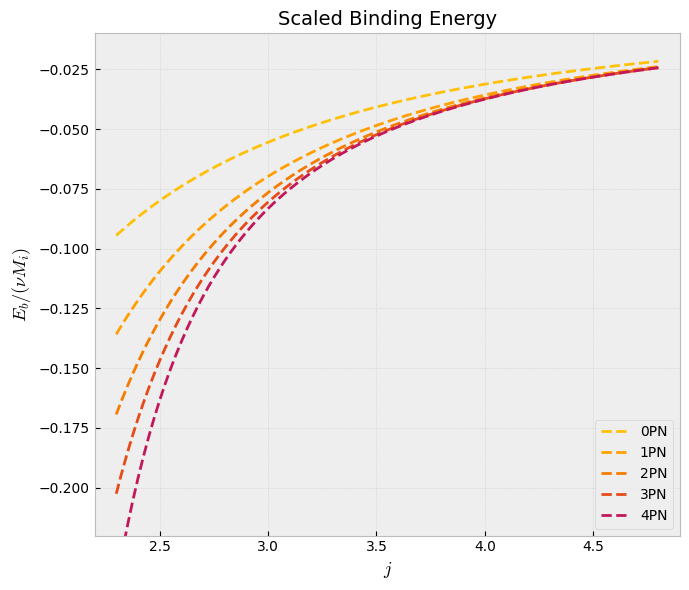

In [16]:
#FIGURE 3 - BINDING ENERGY
nu_val = 0.25
j_grid = np.linspace(2.3, 4.8, 200)
colors_map = {0: '#ffc107', 1: '#ffa000', 2: '#f57c00', 3: '#e64a19', 4: '#c2185b'}

plt.figure(figsize=(7, 6))

for o in PN_orders:
    
    eb_scaled = [(PN_mass(nu_val, j, o) - 1.0) / nu_val for j in j_grid]
    plt.plot(j_grid, eb_scaled, color=colors_map[o], linestyle='--', label=f'{o}PN', linewidth=2)

plt.title("Scaled Binding Energy", fontsize=14)
plt.xlabel(r"$j$", fontsize=13)
plt.ylabel(r"$E_b / (\nu M_i)$", fontsize=13)
plt.xlim(2.2, 4.9)
plt.ylim(-0.22, -0.01)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()